In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append("..")
from cleaning.utils import get_experience_level

sns.set_theme(style="whitegrid")

# Consistent color used across all charts in this notebook and the
# Streamlit dashboard, for a unified look.
MAIN_COLOR = "#0B7285"

df_jobs = pd.read_csv("../data/processed/jobs_clean.csv")
df_skills = pd.read_csv("../data/processed/skills_clean.csv")

## Top 15 most in-demand skills

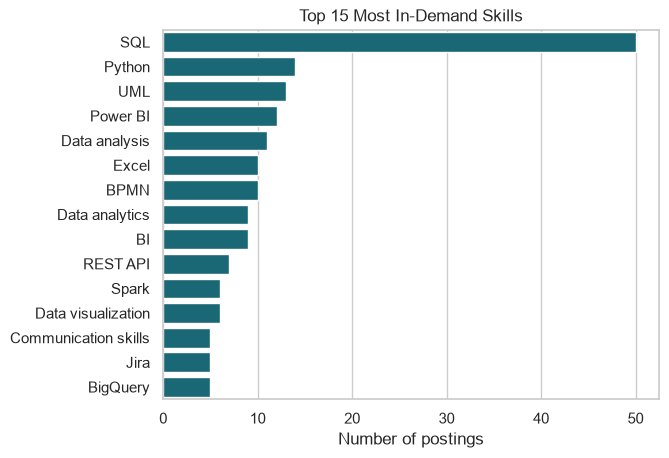

In [3]:
top_skills_df = df_skills["skills"].value_counts().head(15).reset_index()
top_skills_df.columns = ["skill", "count"]

sns.barplot(data=top_skills_df, x="count", y="skill", color=MAIN_COLOR)
plt.title("Top 15 Most In-Demand Skills")
plt.xlabel("Number of postings")
plt.ylabel("")
# plt.show() suppresses the raw Axes object output that Jupyter
# would otherwise print above the chart.
plt.show()

SQL towers over every other skill - the chart makes the gap impossible
to miss. Everything past the top 4-5 skills tails off gradually,
suggesting a few "must-have" tools and a long list of nice-to-haves.

## Salary distribution

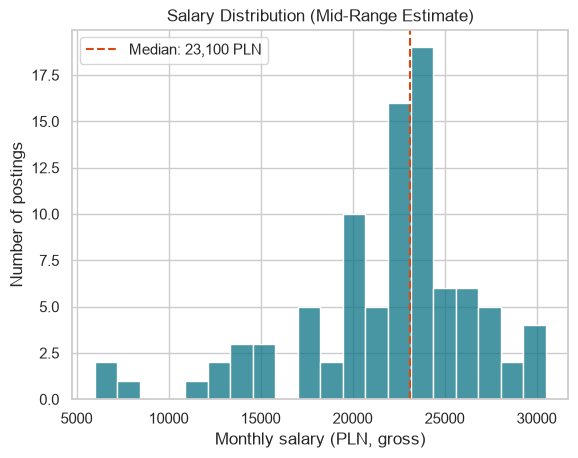

In [4]:
median_salary = df_jobs["mid_salary"].median()

sns.histplot(df_jobs["mid_salary"], color=MAIN_COLOR, bins=20)
plt.axvline(x=median_salary, color="#D9480F", linestyle="--", label=f"Median: {median_salary:,.0f} PLN")
plt.title("Salary Distribution (Mid-Range Estimate)")
plt.xlabel("Monthly salary (PLN, gross)")
plt.ylabel("Number of postings")
plt.legend()
plt.show()

Most salaries cluster tightly around the median (23,100 PLN), with a
visible secondary cluster around 15,000-19,000 PLN - possibly reflecting
less senior or hybrid roles. The distribution has a long tail toward
higher salaries, typical of senior/specialized postings.

## Seniority distribution across postings

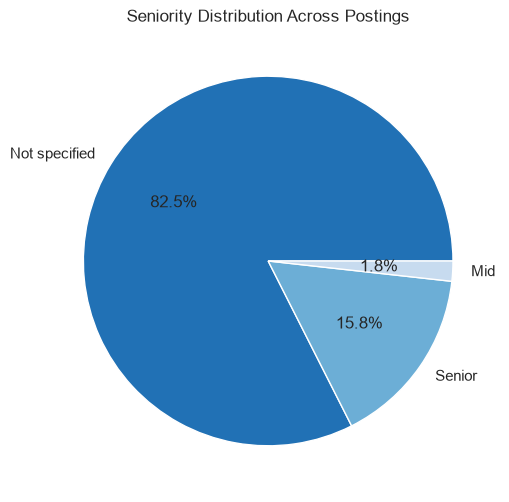

In [5]:
df_jobs["experience_level"] = df_jobs["title"].apply(get_experience_level)

level_counts = df_jobs["experience_level"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(level_counts, labels=level_counts.index, autopct="%1.1f%%", colors=sns.color_palette("Blues_r", len(level_counts)))
plt.title("Seniority Distribution Across Postings")
plt.show()

82.5% of postings don't mention a seniority level in the title at all.
This makes a reliable salary comparison by experience level impossible
with this dataset - the few postings that do specify a level (Senior:
18, Mid: 2, Junior: 0) are too small a sample to draw solid conclusions
from.

## English requirement and remote work

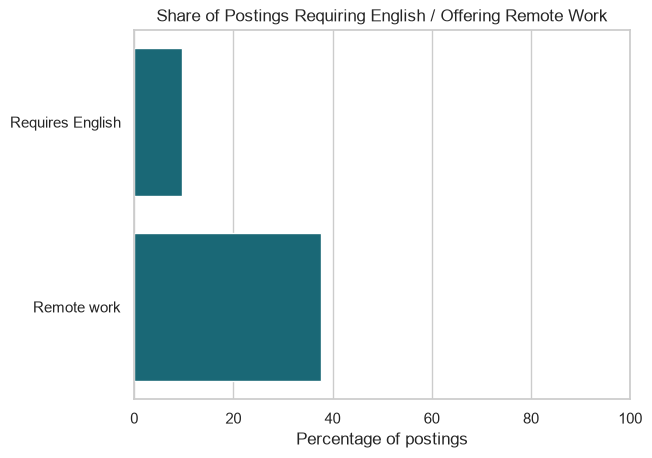

In [6]:
pct_english = df_jobs["has_english"].mean() * 100
pct_remote = df_jobs["is_remote"].mean() * 100

summary_df = pd.DataFrame({
    "category": ["Requires English", "Remote work"],
    "percentage": [pct_english, pct_remote],
})

sns.barplot(data=summary_df, x="percentage", y="category", color=MAIN_COLOR)
plt.title("Share of Postings Requiring English / Offering Remote Work")
plt.xlabel("Percentage of postings")
plt.ylabel("")
plt.xlim(0, 100)
plt.show()

Kraków and Warszawa dominate on-site postings, together accounting for
the majority of location-specific offers. Smaller cities trail well
behind, each with just a handful of postings. Note: postings listed at
multiple cities are counted only under their primary location, so this
may understate totals for some cities (see NOTES.md).

## Top cities for on-site postings

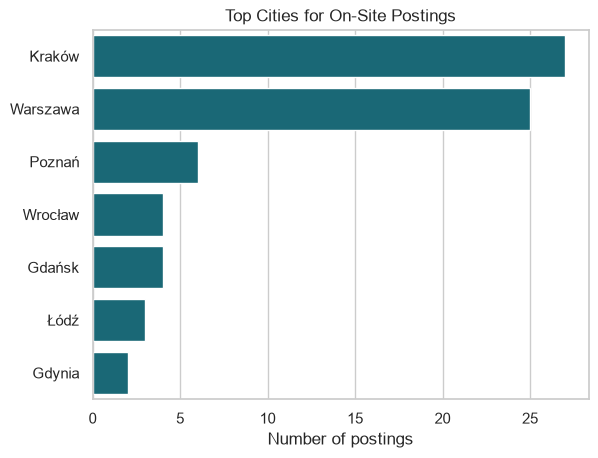

In [7]:
on_site_df = df_jobs[df_jobs["location"] != "Zdalnie"]
top_cities = on_site_df["location"].value_counts().head(10).reset_index()
top_cities.columns = ["city", "count"]

sns.barplot(data=top_cities, x="count", y="city", color=MAIN_COLOR)
plt.title("Top Cities for On-Site Postings")
plt.xlabel("Number of postings")
plt.ylabel("")
plt.show()

Kraków and Warszawa dominate on-site postings, together accounting for
the majority of location-specific offers. Smaller cities trail well
behind, each with just a handful of postings.

## Top companies posting these roles

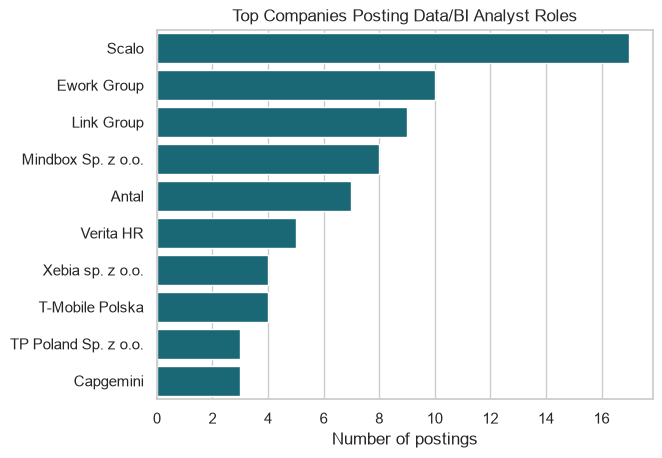

In [8]:
top_companies = df_jobs["company"].value_counts().head(10).reset_index()
top_companies.columns = ["company", "count"]

sns.barplot(data=top_companies, x="count", y="company", color=MAIN_COLOR)
plt.title("Top Companies Posting Data/BI Analyst Roles")
plt.xlabel("Number of postings")
plt.ylabel("")
plt.show()

A handful of recruitment agencies and software houses post the most
offers — worth noting these represent multiple clients, not one
company's in-house team (see NOTES.md).

## Bonus: Which skills correlate with higher salaries?

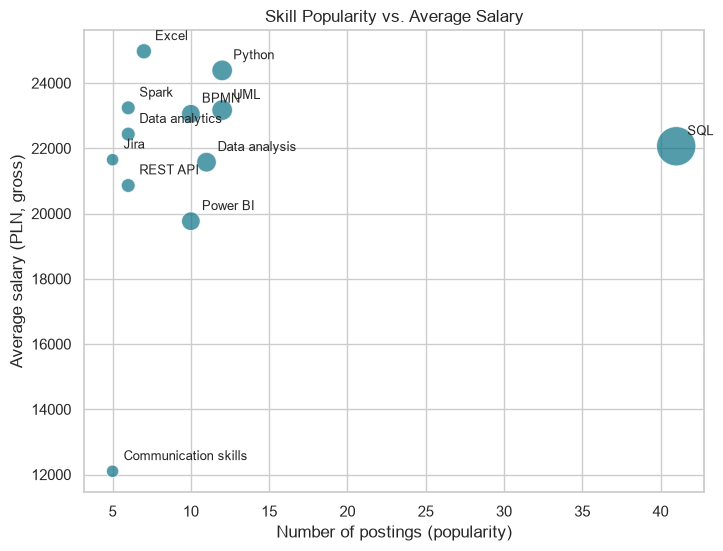

In [9]:
merged = df_skills[df_skills["mid_salary"].notna()]

skill_salary = merged.groupby("skills")["mid_salary"].agg(["mean", "count"]).reset_index()
skill_salary = skill_salary[skill_salary["count"] >= 5]
skill_salary = skill_salary.sort_values("mean", ascending=False)
skill_salary

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=skill_salary,
    x="count",
    y="mean",
    size="count",
    sizes=(80, 800),
    color=MAIN_COLOR,
    alpha=0.7,
    legend=False,
)

for _, row in skill_salary.iterrows():
    plt.annotate(
        row["skills"],
        (row["count"], row["mean"]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=9,
    )

plt.title("Skill Popularity vs. Average Salary")
plt.xlabel("Number of postings (popularity)")
plt.ylabel("Average salary (PLN, gross)")
plt.show()

SQL's bubble dwarfs everything else — by far the most in-demand skill,
though its salary sits mid-pack (~22,400 PLN). Excel and Python command
the highest average salaries despite being far less common. Notably,
"Communication skills" — the only soft skill in this view — has both
low demand and the lowest average salary, suggesting employers value
it less as a standalone requirement compared to technical tools.